In [1]:
import pandas as pd

df = pd.read_excel("payflow_invoice_late_payment_dataset.xlsx")
df.head()

,Invoice_ID,Customer_Segment,Industry,Region,Invoice_Month,Invoice_Amount,Payment_Terms_Days,Customer_Tenure_Months,Prior_Late_Payments,Avg_Days_To_Pay,Days_Since_Last_Order,Dispute_Flag,Reminder_Count,Online_Portal_Use,Early_Payment_Discount_Offered,Credit_Score_Band,Late_Payment
0,INV-20260001,Small Business,Construction,Prairies,Aug,5851.94,30,28,1,42,156,No,3,Yes,No,Medium,Yes
1,INV-20260002,Small Business,Healthcare Services,British Columbia,Aug,3224.65,30,34,2,47,153,Yes,2,Yes,No,High,No
2,INV-20260003,Mid-Market,Retail,Prairies,Dec,17946.67,30,12,2,38,19,No,2,No,No,High,Yes
3,INV-20260004,Small Business,Retail,British Columbia,Sep,5131.03,15,25,5,49,107,No,4,Yes,No,Low,Yes
4,INV-20260005,Mid-Market,Technology,Alberta,Aug,17553.63,60,14,0,61,46,No,2,Yes,No,Medium,Yes


In [2]:
print(df.shape)

(360, 17)


In [3]:
print(df.columns.tolist())

['Invoice_ID', 'Customer_Segment', 'Industry', 'Region', 'Invoice_Month', 'Invoice_Amount', 'Payment_Terms_Days', 'Customer_Tenure_Months', 'Prior_Late_Payments', 'Avg_Days_To_Pay', 'Days_Since_Last_Order', 'Dispute_Flag', 'Reminder_Count', 'Online_Portal_Use', 'Early_Payment_Discount_Offered', 'Credit_Score_Band', 'Late_Payment']


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 360 entries, 0 to 359
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Invoice_ID                      360 non-null    object 
 1   Customer_Segment                360 non-null    object 
 2   Industry                        360 non-null    object 
 3   Region                          360 non-null    object 
 4   Invoice_Month                   360 non-null    object 
 5   Invoice_Amount                  360 non-null    float64
 6   Payment_Terms_Days              360 non-null    int64  
 7   Customer_Tenure_Months          360 non-null    int64  
 8   Prior_Late_Payments             360 non-null    int64  
 9   Avg_Days_To_Pay                 360 non-null    int64  
 10  Days_Since_Last_Order           360 non-null    int64  
 11  Dispute_Flag                    360 non-null    object 
 12  Reminder_Count                  360 

In [5]:
print(df.isnull().sum())

Invoice_ID                        0
Customer_Segment                  0
Industry                          0
Region                            0
Invoice_Month                     0
Invoice_Amount                    0
Payment_Terms_Days                0
Customer_Tenure_Months            0
Prior_Late_Payments               0
Avg_Days_To_Pay                   0
Days_Since_Last_Order             0
Dispute_Flag                      0
Reminder_Count                    0
Online_Portal_Use                 0
Early_Payment_Discount_Offered    0
Credit_Score_Band                 0
Late_Payment                      0
dtype: int64


In [6]:
print(df.duplicated().sum())

0


In [7]:
print("Target distribution:")
print(df["Late_Payment"].value_counts())

Target distribution:
Late_Payment
No     201
Yes    159
Name: count, dtype: int64


In [8]:
df_clean = df.copy()

print("Shape after cleaning:", df_clean.shape)
print("Missing values:", df_clean.isnull().sum().sum())
print("Duplicate rows:", df_clean.duplicated().sum())

Shape after cleaning: (360, 17)
Missing values: 0
Duplicate rows: 0


In [9]:
numeric_columns = [
    "Invoice_Amount", "Payment_Terms_Days", "Customer_Tenure_Months",
    "Prior_Late_Payments", "Avg_Days_To_Pay", "Days_Since_Last_Order",
    "Reminder_Count"
]

categorical_columns = [
    "Customer_Segment", "Industry", "Region", "Invoice_Month",
    "Dispute_Flag", "Online_Portal_Use",
    "Early_Payment_Discount_Offered", "Credit_Score_Band"
]

feature_columns = numeric_columns + categorical_columns

X = df_clean[feature_columns]
y = df_clean["Late_Payment"].map({"No": 0, "Yes": 1})

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)
print()
print("Target distribution after encoding:")
print(y.value_counts())

Shape of X: (360, 15)
Shape of y: (360,)

Target distribution after encoding:
Late_Payment
0    201
1    159
Name: count, dtype: int64


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape: ", y_test.shape)

X_train shape: (288, 15)
X_test shape:  (72, 15)
y_train shape: (288,)
y_test shape:  (72,)


In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_columns),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

# Build full list of processed feature names (for feature importance later)
processed_feature_names = numeric_columns + list(
    preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_columns)
)

print("X_train shape after preprocessing:", X_train_processed.shape)
print("X_test shape after preprocessing: ", X_test_processed.shape)
print("Total processed features:", len(processed_feature_names))

X_train shape after preprocessing: (288, 43)
X_test shape after preprocessing:  (72, 43)
Total processed features: 43


In [12]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

decision_tree_model.fit(X_train_processed, y_train)
print("Decision Tree model trained successfully.")
print(decision_tree_model)

Decision Tree model trained successfully.
DecisionTreeClassifier(max_depth=4, random_state=42)


In [13]:
y_train_pred = decision_tree_model.predict(X_train_processed)
y_test_pred  = decision_tree_model.predict(X_test_processed)

print("First 10 test predictions (0 = On Time, 1 = Late):", y_test_pred[:10])

First 10 test predictions (0 = On Time, 1 = Late): [0 0 1 0 1 1 1 0 0 1]


In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[28 12]
 [13 19]]


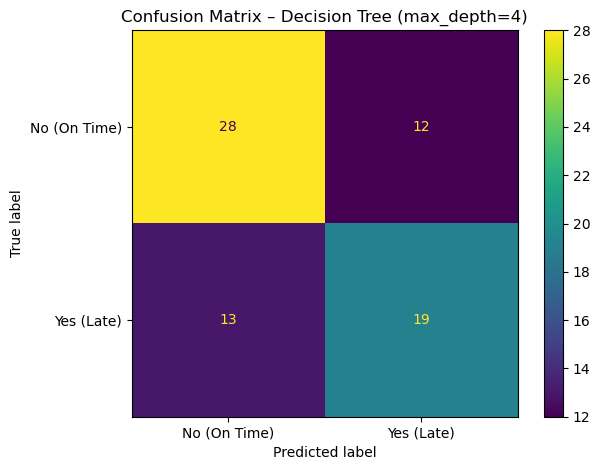

In [15]:
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No (On Time)", "Yes (Late)"]
).plot()
plt.title("Confusion Matrix – Decision Tree (max_depth=4)")
plt.tight_layout()
plt.show()

In [16]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report
)

accuracy  = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred, zero_division=0)
recall    = recall_score(y_test, y_test_pred, zero_division=0)
f1        = f1_score(y_test, y_test_pred, zero_division=0)

print("Decision Tree (max_depth=4) – Test Set Metrics")
print("-" * 50)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

Decision Tree (max_depth=4) – Test Set Metrics
--------------------------------------------------
Accuracy:  0.6528
Precision: 0.6129
Recall:    0.5938
F1-score:  0.6032


In [17]:
print("Full Classification Report:")
print(classification_report(y_test, y_test_pred,
                            target_names=["No (On Time)", "Yes (Late)"],
                            zero_division=0))

Full Classification Report:
              precision    recall  f1-score   support

No (On Time)       0.68      0.70      0.69        40
  Yes (Late)       0.61      0.59      0.60        32

    accuracy                           0.65        72
   macro avg       0.65      0.65      0.65        72
weighted avg       0.65      0.65      0.65        72



In [18]:
# Controlled tree accuracies
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy  = accuracy_score(y_test,  y_test_pred)

print("Controlled Decision Tree (max_depth = 4)")
print(f"  Training Accuracy: {train_accuracy:.4f}")
print(f"  Testing Accuracy:  {test_accuracy:.4f}")
print(f"  Gap (train - test): {train_accuracy - test_accuracy:.4f}")

Controlled Decision Tree (max_depth = 4)
  Training Accuracy: 0.7639
  Testing Accuracy:  0.6528
  Gap (train - test): 0.1111


In [19]:
# Compare with an unrestricted (overfit) tree
overfit_tree_model = DecisionTreeClassifier(max_depth=None, random_state=42)
overfit_tree_model.fit(X_train_processed, y_train)

y_train_pred_overfit = overfit_tree_model.predict(X_train_processed)
y_test_pred_overfit  = overfit_tree_model.predict(X_test_processed)

overfit_train_acc = accuracy_score(y_train, y_train_pred_overfit)
overfit_test_acc  = accuracy_score(y_test,  y_test_pred_overfit)

print("Unrestricted Decision Tree (max_depth = None)")
print(f"  Training Accuracy: {overfit_train_acc:.4f}")
print(f"  Testing Accuracy:  {overfit_test_acc:.4f}")
print(f"  Gap (train - test): {overfit_train_acc - overfit_test_acc:.4f}")

Unrestricted Decision Tree (max_depth = None)
  Training Accuracy: 1.0000
  Testing Accuracy:  0.5833
  Gap (train - test): 0.4167


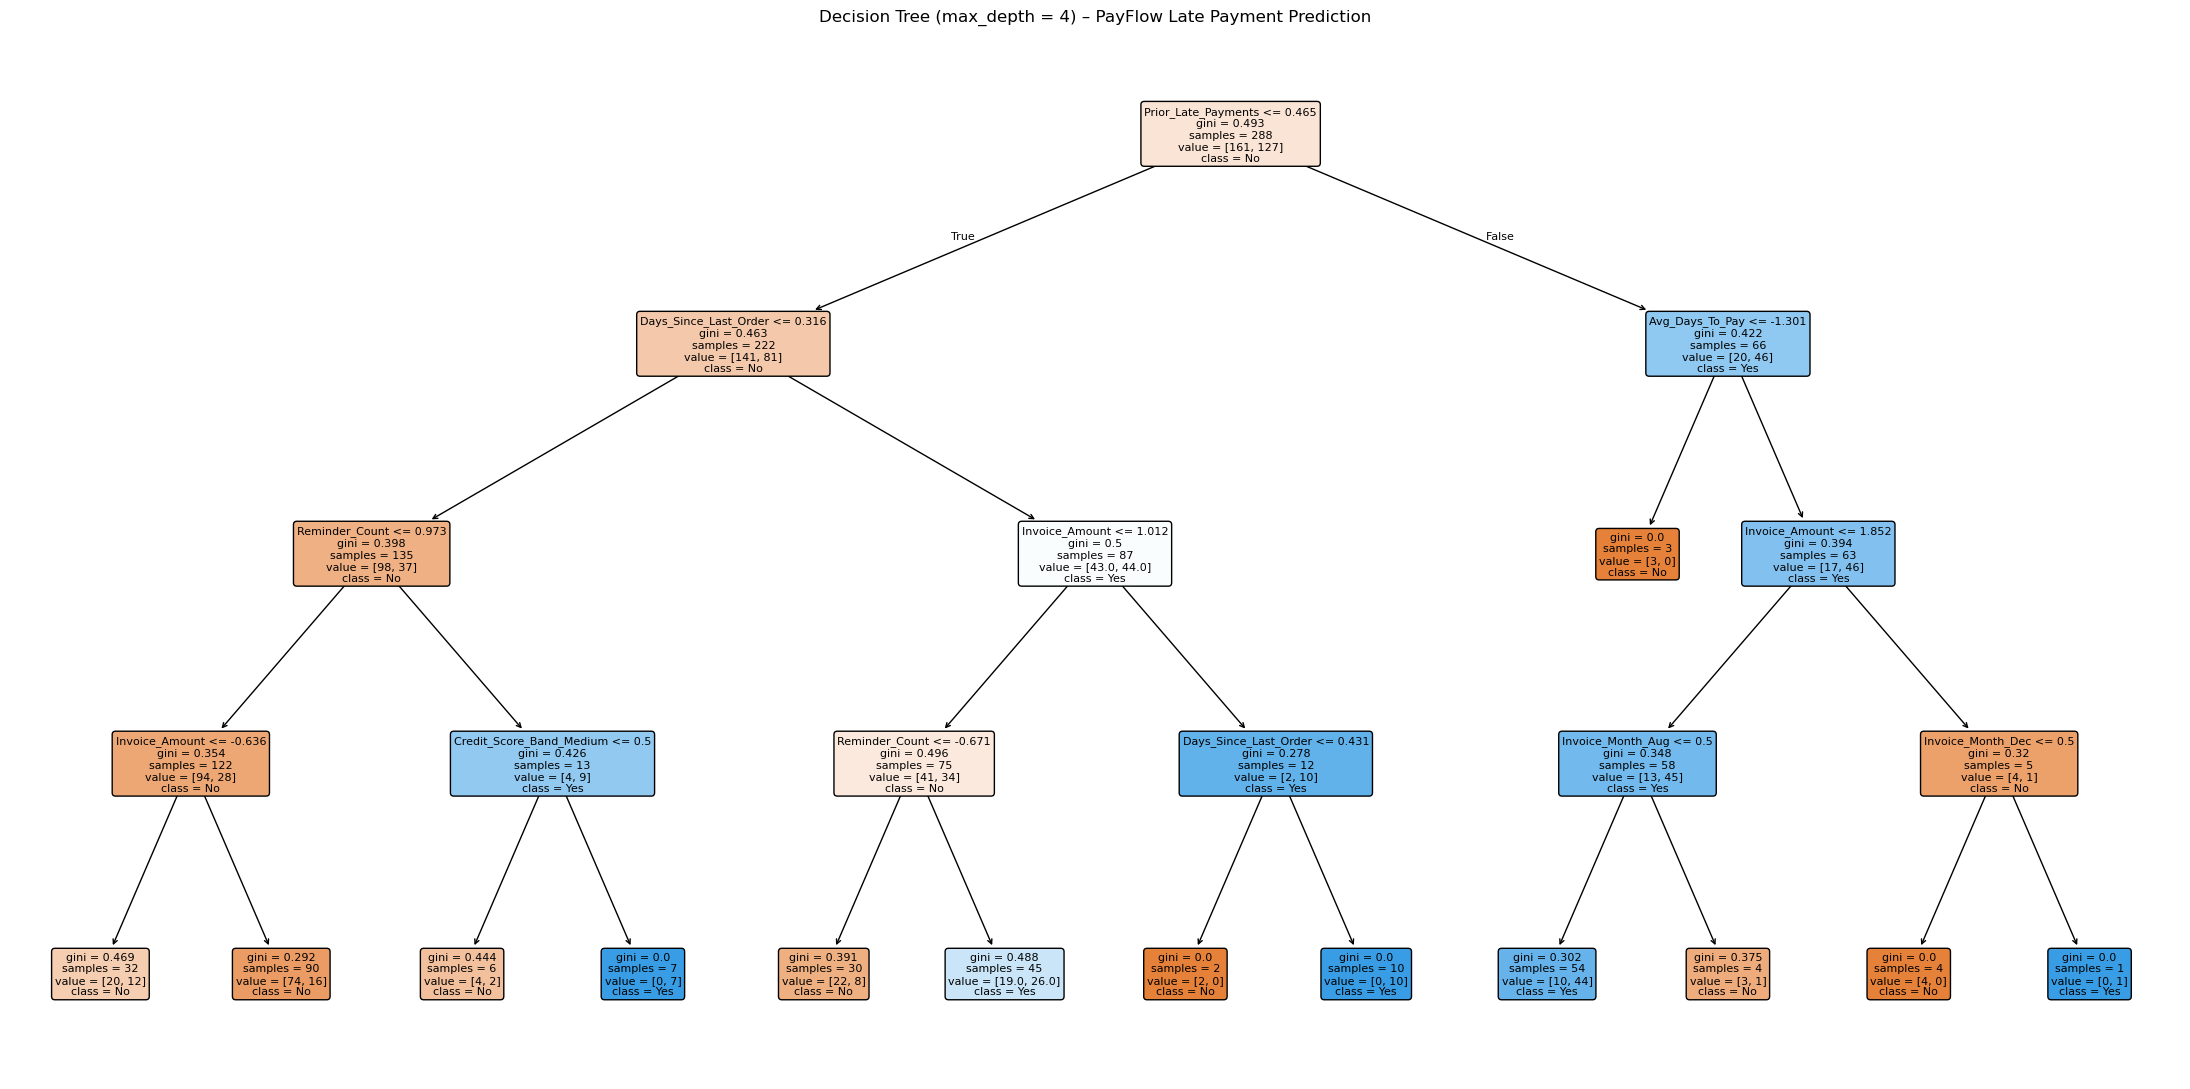

In [20]:
from sklearn.tree import plot_tree

plt.figure(figsize=(22, 11))
plot_tree(
    decision_tree_model,
    feature_names=processed_feature_names,
    class_names=["No", "Yes"],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Decision Tree (max_depth = 4) – PayFlow Late Payment Prediction")
plt.tight_layout()
plt.show()

In [21]:
dt_feature_importance = pd.DataFrame({
    "Feature": processed_feature_names,
    "Importance": decision_tree_model.feature_importances_
}).sort_values(by="Importance", ascending=False).reset_index(drop=True)

print("Top 10 Most Important Features:")
display(dt_feature_importance.head(10))

Top 10 Most Important Features:


,Feature,Importance
0,Prior_Late_Payments,0.241185
1,Days_Since_Last_Order,0.193691
2,Reminder_Count,0.183042
3,Invoice_Amount,0.169288
4,Avg_Days_To_Pay,0.065622
5,Credit_Score_Band_Medium,0.061719
6,Invoice_Month_Aug,0.051066
7,Invoice_Month_Dec,0.034386
8,Invoice_Month_Sep,0.000000
9,Invoice_Month_Jul,0.000000


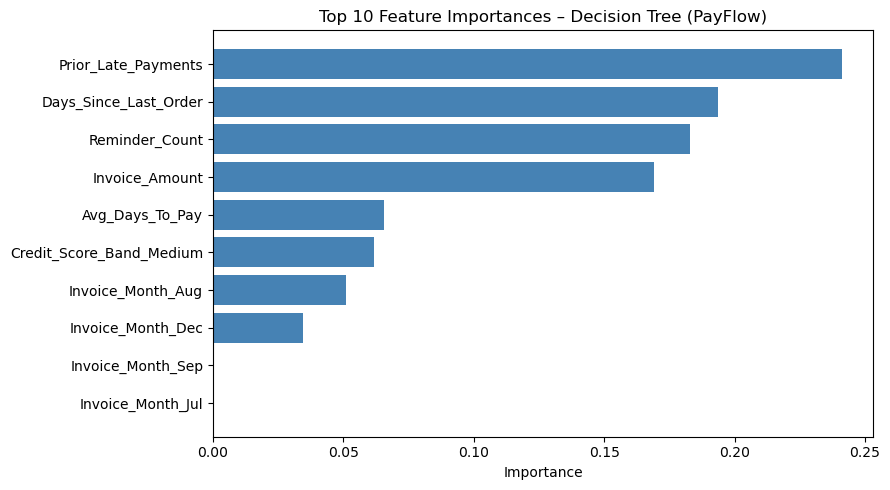

In [22]:
# Bar chart of top 10 feature importances
top10 = dt_feature_importance.head(10)

plt.figure(figsize=(9, 5))
plt.barh(top10["Feature"][::-1], top10["Importance"][::-1], color="steelblue")
plt.title("Top 10 Feature Importances – Decision Tree (PayFlow)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [23]:
### Final Business Interpretation

**How well did the Decision Tree model perform?**
On the held-out test set the controlled Decision Tree (`max_depth=4`) achieved **Accuracy = 0.6528, Precision = 0.6129, Recall = 0.5938, F1 = 0.6032**. The dataset is moderately imbalanced (56% No / 44% Yes), so accuracy alone is not the best single metric. The model is performing at a moderate level — correctly identifying late-payment invoices more often than chance, but with room for improvement through hyperparameter tuning, additional features, or ensemble methods.

**Is there a large difference between training accuracy and testing accuracy?**
Yes. The controlled tree scores 0.7639 on training data versus 0.6528 on the test set — a gap of 0.1111. For the unrestricted tree the gap widens dramatically to 0.4167 (training accuracy 1.0000, test accuracy 0.5833). This confirms that depth restriction meaningfully reduces overfitting. A 0.1111 gap in the controlled model indicates moderate overfitting is still present, suggesting that further tuning (e.g. adjusting `min_samples_leaf`, `min_samples_split`, or using cross-validation) could further improve test-set performance.

**Does the model show signs of overfitting? Why or why not?**
The controlled tree (`max_depth=4`) shows **moderate overfitting**: there is a 0.1111 gap between training and testing accuracy. The unrestricted tree shows **severe overfitting** — a 0.4167 gap — because it grows enough branches to memorise every training sample. The relatively low test-set accuracy for the unrestricted model (0.5833) is actually *worse* than the controlled model, proving that memorisation does not help on new data.

**Which evaluation metric is most important for this business problem?**
**Recall for the Late class** is the most critical single metric. Missing a genuinely late invoice (a false negative) means PayFlow fails to intervene early, cash flow is disrupted, and the eventual collection effort becomes more expensive. However, **F1-score** should be monitored jointly: excessive false positives mean reliable customers receive unnecessary reminders, which can damage the customer relationship and increase operational workload unnecessarily. With a recall of 0.5938, the model catches roughly 59% of truly late invoices — adequate as a decision-support tool, but the team should set an alert threshold to improve coverage.

**What do false positives mean in this business context?**
The model predicts an invoice will be late, but it is actually paid on time. In practical terms, PayFlow sends an early reminder or assigns account manager attention to a customer who would have paid without any prompting. This wastes staff time and may irritate reliable, long-standing clients if the communication feels intrusive or implies distrust. With 12 false positives in this test set, approximately 12 customers received an unnecessary intervention.

**What do false negatives mean in this business context?**
The model predicts an invoice will be paid on time, but it is actually late. PayFlow misses the opportunity to intervene before the due date, leading to delayed cash inflows, potentially triggering the need for a more aggressive and costly collection process later. With 13 false negatives in this test set, 13 genuinely risky invoices went unidentified — the more costly error type for this business.

**Which features were most important in the Decision Tree model?**
The top drivers of late payment risk are:
1. **Prior_Late_Payments** (0.2412) – the strongest single predictor. Customers with a history of late payments are far more likely to pay late again.
2. **Days_Since_Last_Order** (0.1937) – customers who have not transacted recently may be experiencing financial difficulty or reduced engagement.
3. **Reminder_Count** (0.1830) – higher reminder counts are associated with late payment; customers requiring repeated prompting tend to pay late.
4. **Invoice_Amount** (0.1693) – larger invoices take longer to approve internally and are more likely to be delayed.
5. **Avg_Days_To_Pay** (0.0656) – a customer's historical average payment speed is a reliable forward indicator.
6. **Credit_Score_Band_Medium** (0.0617) – medium credit bands carry elevated risk compared to high-band customers.

**How can these important features help the business act earlier?**
- **Prior_Late_Payments**: flag all invoices from customers with ≥1 prior late payment for automatic early reminder workflows.
- **Days_Since_Last_Order**: set a threshold (e.g., >90 days) to trigger a proactive account manager check-in before the invoice is even issued.
- **Reminder_Count**: if a customer already has a high reminder count on other open invoices, escalate the new invoice immediately to a senior account manager.
- **Invoice_Amount**: for high-value invoices, deploy a dedicated payment concierge to confirm receipt and approval on the buyer's side well before the due date.
- **Avg_Days_To_Pay**: use the customer's historical average to set invoice-specific follow-up schedules rather than a one-size-fits-all reminder cadence.
- **Credit_Score_Band**: integrate credit band into the automated triage model to escalate medium- and low-band customers by default.

**What is one possible limitation or bias in the model or dataset?**
The dataset is **synthetic and contains only 360 rows**, which limits the statistical reliability of learned patterns, especially for categorical features like `Industry` and `Region`. With a small dataset, some combinations (e.g., a specific industry in a specific region) may appear very rarely, and the model may learn spurious rules. Additionally, the model may associate certain industries or customer segments with late payment without considering legitimate structural differences (e.g., construction clients having longer payment approval cycles by contract). Managers should review predictions involving specific industry or region combinations carefully before taking action.

**Why should human judgment still be used when making business decisions based on model results?**
- The model's recall of 0.5938 means roughly 40% of genuinely late invoices are missed. Sole reliance on the model would leave a significant number of at-risk invoices unmonitored.
- Account managers hold relationship context — long-term strategic clients, known seasonal cash-flow patterns, or recent contract amendments — that no dataset can fully capture.
- Large-account decisions (e.g., pausing service, applying interest penalties, or escalating to legal) carry reputational and relationship risks that require human review.
- The model should function as an **early warning and triage tool** that prioritises the daily worklist, not an automated collection system that bypasses human judgment.

SyntaxError: invalid character '—' (U+2014) (3824519093.py, line 4)